# Côa Valley Eco-Connectivity: Land, Water, Air

**Rewilding Portugal / Solo Field Illustrator project — scientific track**

This notebook builds three species-group connectivity rasters (land, water, air) for a 30km-radius corridor around the Côa River, following the multi-species framework in Prima et al. (2024), *Methods in Ecology and Evolution* 15:2385–2399 (`Methods Ecol Evol - 2024 - Prima - A comprehensive framework to assess multi‐species landscape connectivity.pdf`, in this folder). It is the Python/QGIS "scientific" track referenced in `storyMaps/scratch.md` — reproducible modelling that supplies finished map images to the community-facing ArcGIS StoryMap, kept separate from the narrative itself.

Every script this notebook orchestrates lives in `scripts/` and can also be run standalone. Data provenance is explicit throughout: what came from already-cached official EU/GBIF downloads (in the sibling `data-management` repo), what was pulled fresh from online sources for this analysis, and what came from this project's own field work.

In [1]:
import os
os.chdir("../scripts")

from IPython.display import Image, display
import sys
sys.path.insert(0, "..")
import config

## Framing: safe and just

Two commitments run through every section below, not just the eco-tourism discussion at the end:

- **Safe** — sensitive-species locations (currently the European wildcat, *Felis silvestris*) are never mapped at exact coordinates; `acquire_field_observations.py` generalises any record mentioning a sensitive species to a 5km grid cell before it reaches any figure, map, or export, per the open data-handling item in `survey123/memo-data-use.md`. Visitor safety is treated the same way as wildlife safety in the human-wildlife-conflict section — a stewardship question, not a reason to restrict access.
- **Just** — eco-tourism recommendations below are checked against the combined connectivity output so they don't concentrate access at the expense of the corridor, and against having more than one access point/municipality rather than favouring whichever town is easiest to reach. Land-tenure context (private reserves, hunting zones) is presented as an open question, not folded silently into the ecological model, because this project has no first-hand knowledge of how any given estate is actually managed.

## Study area and data provenance

The study area is a 30km-radius buffer around the Côa river corridor — wide enough to bring in the surrounding land-tenure context, not just the immediate riparian strip. All raster work runs in EPSG:3035 (matching the sibling `data-management` repo's national base layers); field and GBIF data are handled in EPSG:4326 until reprojected.

In [2]:
%run acquire_study_area.py
%run acquire_field_observations.py
%run acquire_environmental_covariates.py

Study area: 30.0km buffer around 31 Côa river segments
Extent (EPSG:4326): [-7.4775537  40.00246968 -6.53775962 41.35292564]
Area: 9,377 km2
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/study_area.gpkg
12 field visits loaded, 0 flagged sensitive and generalised
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/field_observations.gpkg
Clipping rasters...
  elevation: (1, 1516, 827) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/elevation.tif
  slope_degrees: (1, 1516, 827) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/covariates/slope_degrees.tif
  ruggedness_tri: (1, 1516, 827) -> /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-P

  wrote 01_study_area.png


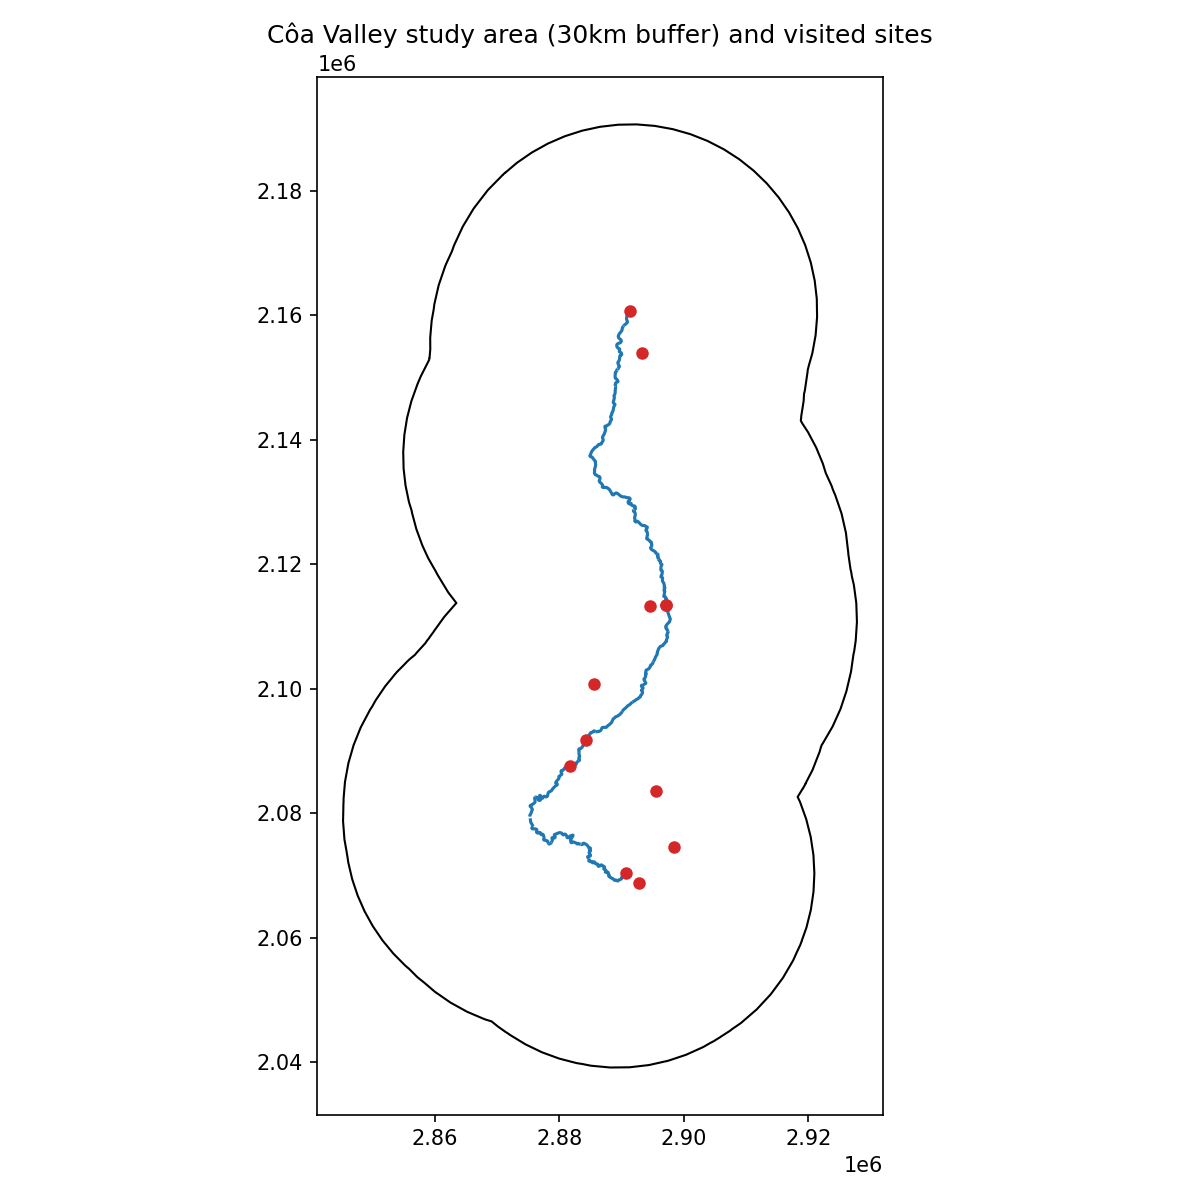

In [3]:
import generate_maps
generate_maps.OUT_DIR.mkdir(parents=True, exist_ok=True)
generate_maps.map_01_study_area()
display(Image(str(config.OUTPUT_MAPS / "01_study_area.png")))

## Method

Prima et al. (2024) build multi-species connectivity in four steps (their Fig. 1, p.2387): (1) cluster species into ecologically meaningful functional groups rather than picking one umbrella species; (2) build a group-level habitat-suitability and resistance surface from occurrence data and environmental covariates; (3) run circuit theory (Omniscape) per group, accounting for parameter uncertainty; (4) overlay the resulting continuities with protected-area networks.

This notebook follows steps 1–3 directly, reframed around **movement medium** — land, water, air — rather than Prima's taxonomic mammal/bird split, matching the categorisation already sketched in `data-management/docs/spp_list/spies_GBIF_doi.md`. Two deliberate simplifications, stated here rather than left implicit:

- **One suitability model per group**, not Prima's four-algorithm ensemble (ANN/XGBoost/random forest/MaxEnt) per species. A single `RandomForestClassifier` (scikit-learn) is trained per group on the pooled occurrence points of its member species against a shared covariate stack.
- **One parameter set per group**, not Prima's uncertainty sweep (their case study runs 12–120 Omniscape calls per group, sampling source threshold, resistance shape *c*, and search radius). Here each group gets a single mid-range resistance shape (*c*=4, their Eq. 1) and a single search radius set from the group's largest member's known dispersal distance.

Both are real limits on how much these results can be trusted quantitatively — flagged again at each relevant step below — but keep the three connectivity rasters this project needs tractable within a single working session.

Circuit theory itself is implemented in pure Python (`scripts/run_omniscape.py`) rather than calling Julia's Omniscape.jl: the same resistance→conductance formulation, moving-window search radius, and current-flow normalisation, solved with `scipy.sparse` — see that script's docstring for why (Julia was ruled out, and the legacy PyPI `circuitscape` package is broken on modern Python).

### Species occurrence data (GBIF)

All nine focal species already have DOI-versioned GBIF downloads cached in the sibling `data-management` repo (`docs/01_data_sources.md`) — no fresh API pull was needed. One data-quality note worth surfacing rather than hiding: several records for sensitive carnivores (the wolf, the wildcat) come with coordinates deliberately generalised by the original recorder to protect the species — one wolf record in this dataset is offset by roughly 28km from its true location. Prima et al.'s own uncertainty filter (<1km, p.2388) would discard almost all of this project's carnivore data, so a 30km threshold is used instead, and the resulting scarcity (38 usable land-group points region-wide) is carried forward honestly rather than smoothed over.

In [4]:
%run acquire_gbif_occurrences.py

  Canis lupus (Canis_lupus): 138 raw -> 137 usable
  Felis silvestris (Felis_silvestris): 7 raw -> 7 usable
  Cervus elaphus (Cervus_elaphus): 733 raw -> 733 usable
Land: 877 total, 38 within 30.0km study area
  Lutra lutra (Lutra_lutra): 1704 raw -> 1701 usable
  Pseudochondrostoma polylepis (P_polylepis): 38 raw -> 38 usable
  Squalius alburnoides (Squalius_alburnoides): 568 raw -> 568 usable
  Emys orbicularis (Emys_orbicularis): 319 raw -> 319 usable
Water: 2626 total, 345 within 30.0km study area
  Gyps fulvus (Gyps_fulvus): 32927 raw -> 32897 usable
  Neophron percnopterus (N_percnopterus): 7139 raw -> 7139 usable
  Aquila chrysaetos (Aquila_chrysaetos): 4139 raw -> 4139 usable
Air: 44175 total, 8411 within 30.0km study area
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/gbif_occurrences.gpkg


### Suitability models and resistance surfaces

One random-forest presence-background model per group, trained on the pooled occurrence points above against a group-specific covariate stack — the land and water groups use the full generalist set (elevation, slope, ruggedness, land cover, distance-to-road, imperviousness); the air group leans on topography alone (elevation, slope, ruggedness, hillshade), since raptor thermal/cliff-corridor connectivity is a genuinely different resistance logic from road-driven terrestrial movement, not a road-avoidance problem. Suitability then converts to resistance via Prima's Eq. 1 (p.2389), single *c*=4 per group.

In [5]:
%run build_suitability_models.py
%run build_resistance_surfaces.py

  land: n_presence=38, n_background=2000, train accuracy=0.99
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/suitability/land_suitability.tif
  water: n_presence=1380, n_background=2000, train accuracy=0.97
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/suitability/water_suitability.tif
  air: n_presence=33644, n_background=2000, train accuracy=0.79
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/suitability/air_suitability.tif
Land: c=4.0, resistance range [1.8, 100.0], mean 87.8
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/resistance/land_resistance.tif
Water: c=4.0, resistance range [1.0, 97.2], mean 73.0
  wrote /home/linda/Documents/myData/Solo-f

The training accuracy printed above (0.80–0.99) is **not a validation metric** — it's fit on the same points used to train, with no held-out test split at this scoping level, and Prima et al. themselves flag connectivity-model validation as a field-wide gap with no movement-tracking data available here to check against (p.2396). The air group's high suitability almost everywhere is a likely artefact of citizen-science recording density (8,411 usable points, heavily biased toward wherever people are, not toward true habitat preference) rather than a real ecological signal — read that raster as "where raptors are recorded," not "where raptors prefer to fly."

### Circuit theory (pure Python)

Each group's resistance and suitability (as the source-strength raster) feed the moving-window solver in `run_omniscape.py`. Runtime note: the solver resamples to 1km resolution for this step specifically — matching Prima et al.'s own resolution choice (p.2388) despite this project having finer source data — which keeps a 9,377km² study area's three group solves under 15 seconds total on a laptop, real per-window circuit solves throughout, not a shortcut approximation.

In [6]:
%run run_omniscape.py

Land (dispersal 80.0km):
    209 windows (radius=80px, block=8px, grid 152x83)
    209 windows (radius=80px, block=8px, grid 152x83)
  normalized_current range [0.748, 1.667], mean 0.995
  wrote land_{current_flow,flow_potential,normalized_current}.tif
Water (dispersal 20.0km):
    3192 windows (radius=20px, block=2px, grid 152x83)
    3192 windows (radius=20px, block=2px, grid 152x83)
  normalized_current range [0.559, 3.750], mean 0.981
  wrote water_{current_flow,flow_potential,normalized_current}.tif
Air (dispersal 100.0km):
    144 windows (radius=100px, block=10px, grid 152x83)
    144 windows (radius=100px, block=10px, grid 152x83)
  normalized_current range [0.239, 6.539], mean 1.048
  wrote air_{current_flow,flow_potential,normalized_current}.tif


### Land — wolf, wildcat, red deer

Reads onto both the Movement chapter (Vale Carapito — Sorraia horses and Tauros cattle under the Endangered Landscapes reintroduction, 23 and 17 head respectively over 656ha, per `storyMaps/scratch.md`) and the Connection chapter (Ribeira do Mosteiro — Rewilding Portugal's SOPHIA corridor-fragmentation argument). Own-photo ground-truth: free-ranging cattle and a possible Sorraia-phenotype horse herd near Almeida/Lageosa (Survey123 field records — flagged unconfirmed, since Vale Carapito and Ermo das Águias are the only official reintroduction sites).

  wrote 03_land_connectivity.png


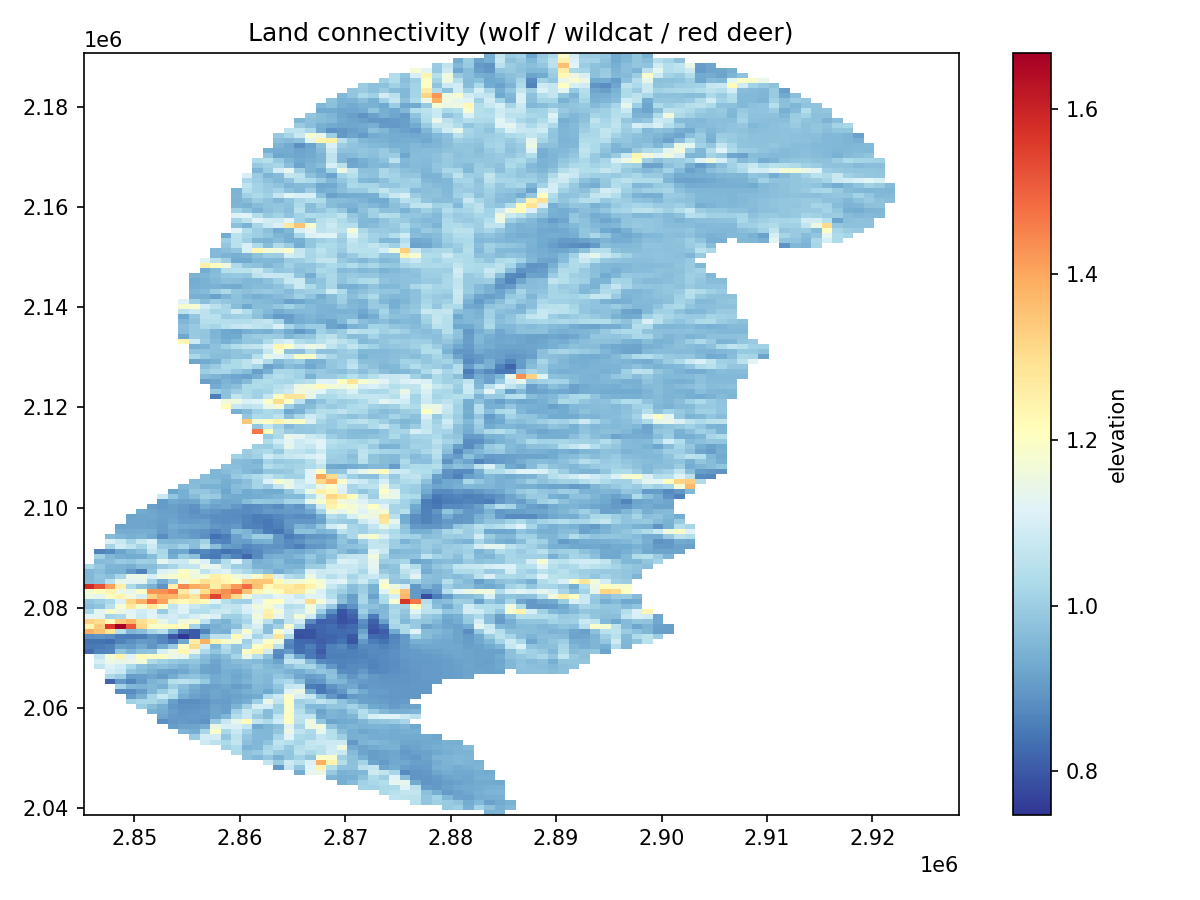

In [7]:
generate_maps._plot_raster(config.OUTPUT_RASTERS / "land_normalized_current.tif",
                            "Land connectivity (wolf / wildcat / red deer)", "RdYlBu_r",
                            out_name="03_land_connectivity.png", cbar_label="normalized current")
display(Image(str(config.OUTPUT_MAPS / "03_land_connectivity.png")))

### Water — otter, native fish, pond turtle

Reads onto the Water chapter (Paul de Toirões restored wetland). Runs against the Côa mainstem plus the barrier cases already documented in the field notes: the Pontão Manuel José weir (a historic ford, now partly submerged by a downstream hydroelectric reservoir) and the Foz Côa cofferdam — built for a dam project halted in 1996 by the "As gravuras não sabem nadar" civic movement, but never demolished, and still periodically flooding 119 rock-art panels today. Own-photo ground-truth: small cyprinid fish and water striders at the Pontão Manuel José pool (Survey123).

  wrote 04_water_connectivity.png


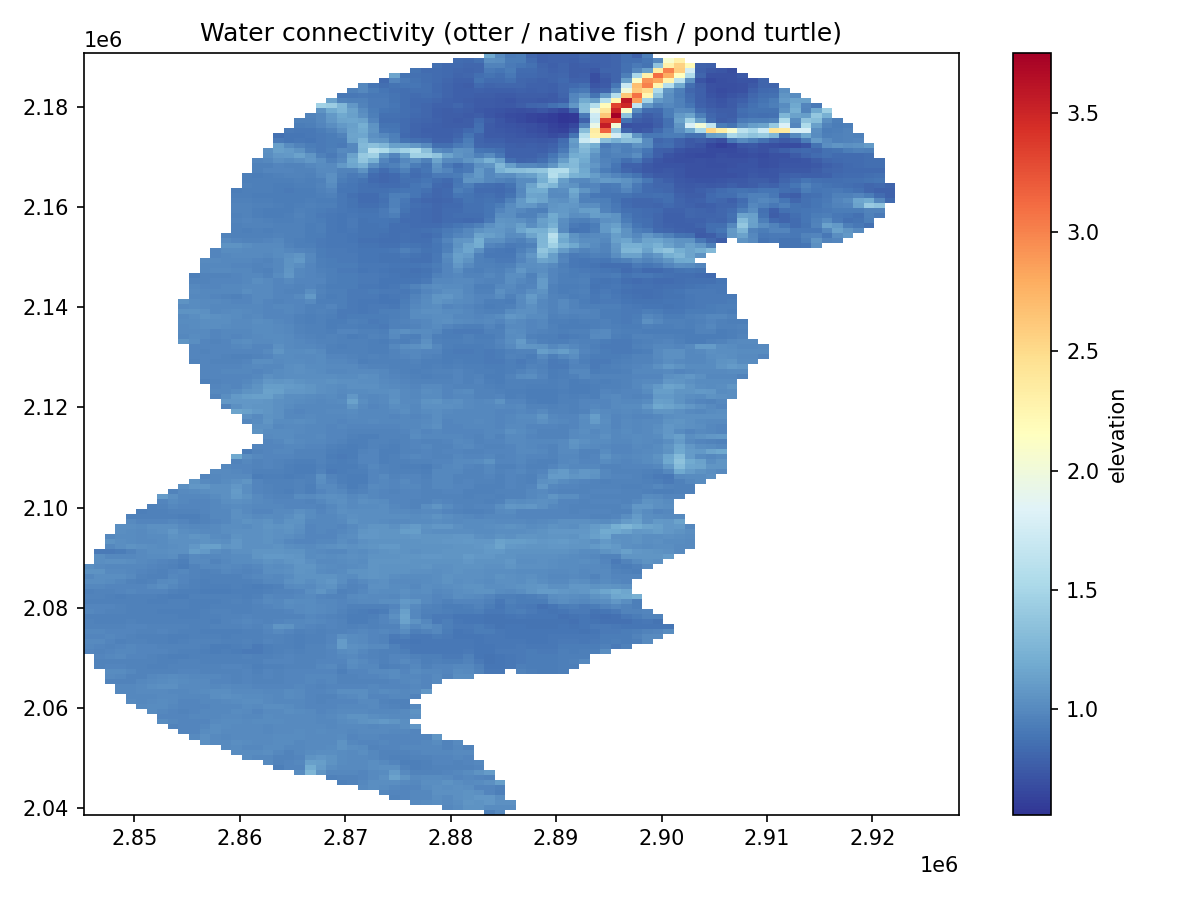

In [8]:
generate_maps._plot_raster(config.OUTPUT_RASTERS / "water_normalized_current.tif",
                            "Water connectivity (otter / native fish / pond turtle)", "RdYlBu_r",
                            out_name="04_water_connectivity.png", cbar_label="normalized current")
display(Image(str(config.OUTPUT_MAPS / "04_water_connectivity.png")))

### Air — griffon vulture, Egyptian vulture, golden eagle

Matches the raptor guild expected over the Douro Superior / Côa gorge (field notes, 15 Aug reconnaissance) — thermal and cliff-corridor connectivity, a different resistance logic from the two ground-based groups (see the Method section's covariate note). No confirmed field sighting yet for this group; the desk-study comparison of the Côa gorge against the Douro's dammed Barragem do Pocinho reservoir is the closest field context.

  wrote 05_air_connectivity.png


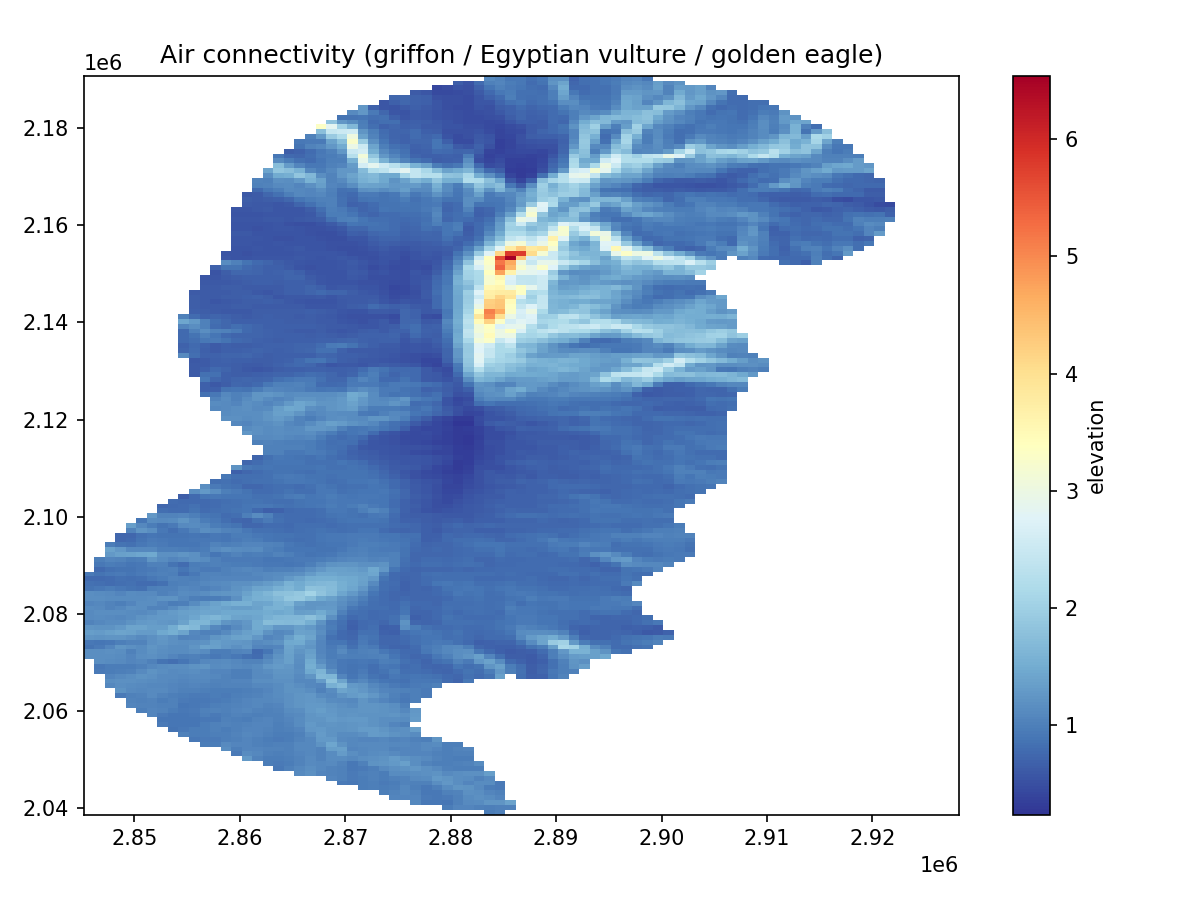

In [9]:
generate_maps._plot_raster(config.OUTPUT_RASTERS / "air_normalized_current.tif",
                            "Air connectivity (griffon / Egyptian vulture / golden eagle)", "RdYlBu_r",
                            out_name="05_air_connectivity.png", cbar_label="normalized current")
display(Image(str(config.OUTPUT_MAPS / "05_air_connectivity.png")))

## Multi-species combined connectivity

Following Prima et al.'s species-count-weighted averaging (p.2389) — Land (3 species), Water (4 species), and Air (3 species) combined into one corridor-prioritisation map. The dendritic, branching pattern visible below is the qualitative signature circuit theory is supposed to produce (current concentrates along corridor structure rather than spreading uniformly) — a useful sanity check in its own right, independent of the validate_results.py checks that follow later.

multispecies_mean_connectivity: range [0.700, 2.637], mean 1.005
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/output/rasters/multispecies_mean_connectivity.tif
multispecies_max_connectivity: range [0.865, 6.539], mean 1.213
  wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/output/rasters/multispecies_max_connectivity.tif
  wrote 06_multispecies_mean.png


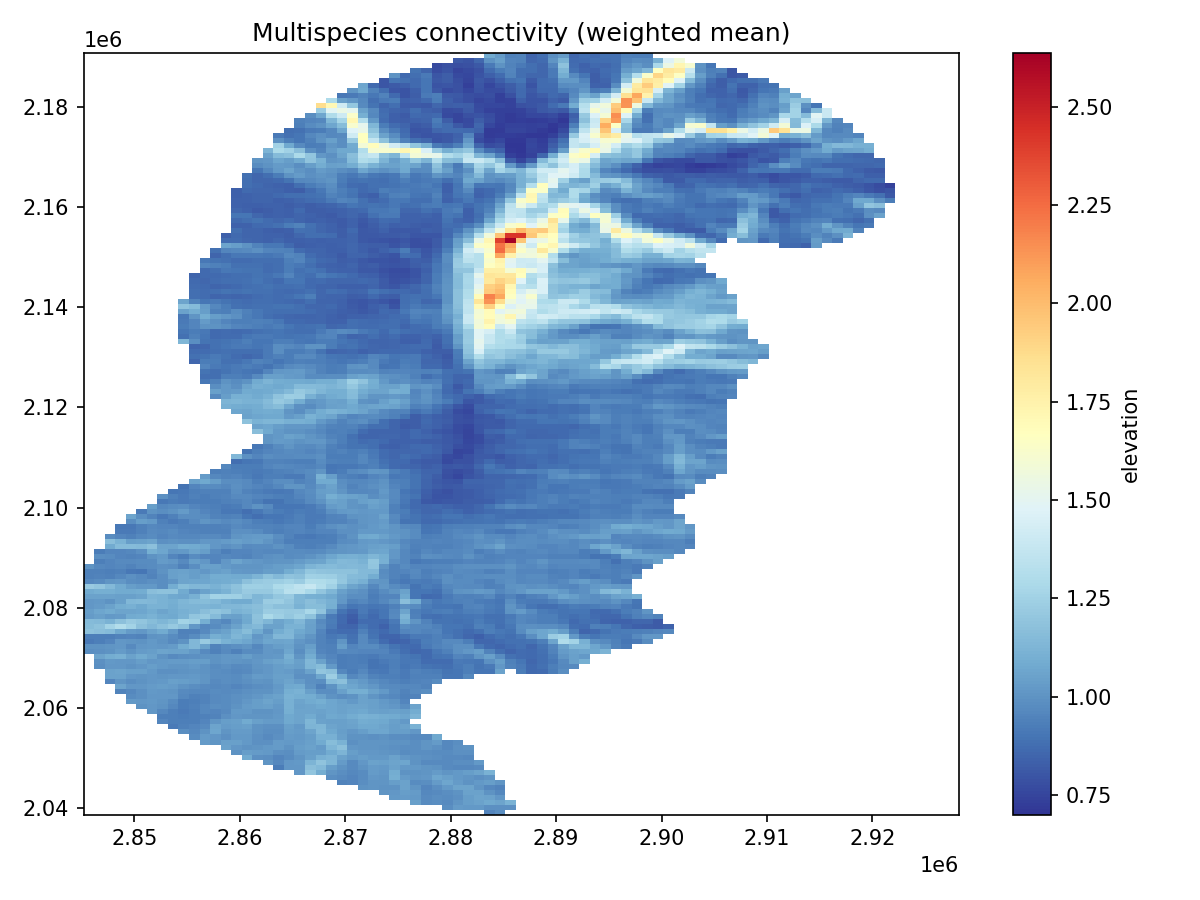

In [10]:
%run combine_connectivity.py
generate_maps._plot_raster(config.OUTPUT_RASTERS / "multispecies_mean_connectivity.tif",
                            "Multispecies connectivity (weighted mean)", "RdYlBu_r",
                            out_name="06_multispecies_mean.png", cbar_label="normalized current")
display(Image(str(config.OUTPUT_MAPS / "06_multispecies_mean.png")))

## Roads and waterways: barrier vs. access

Roads and waterways are simultaneously barriers to reintroduction and access routes for eco-tourism — the same road that fragments a corridor also reaches the Fóios biodiversity trail and the Penascosa rock-art reception; the same river that a fish or otter must cross freely is also what draws visitors to the praia fluviais. Rather than mapping barriers alone, both get classified into: **conservation priority** (high barrier, low tourism value — no development case), **compatible access** (low barrier, high tourism value), and **conflict** (high barrier and high tourism value — flag as wildlife-crossing or seasonal-access candidates, not a default expansion).

The Foz Côa cofferdam is the clearest case in this project's own material of where the two readings *align* rather than trade off: it has high barrier severity for the Water group **and** it directly threatens the rock-art tourism asset it periodically floods. Removing it would serve conservation and heritage tourism at once — worth stating plainly rather than treating every barrier as an inevitable trade-off.

*Simplification note*: the waterway barrier-severity layer reuses the Water group's resistance surface rather than a separate dam/weir point layer (none was built for this pass), so it reflects overall channel permeability, not barrier structures specifically.

Road trade-off maps written
Waterway trade-off maps written
  wrote 07_road_tradeoff.png


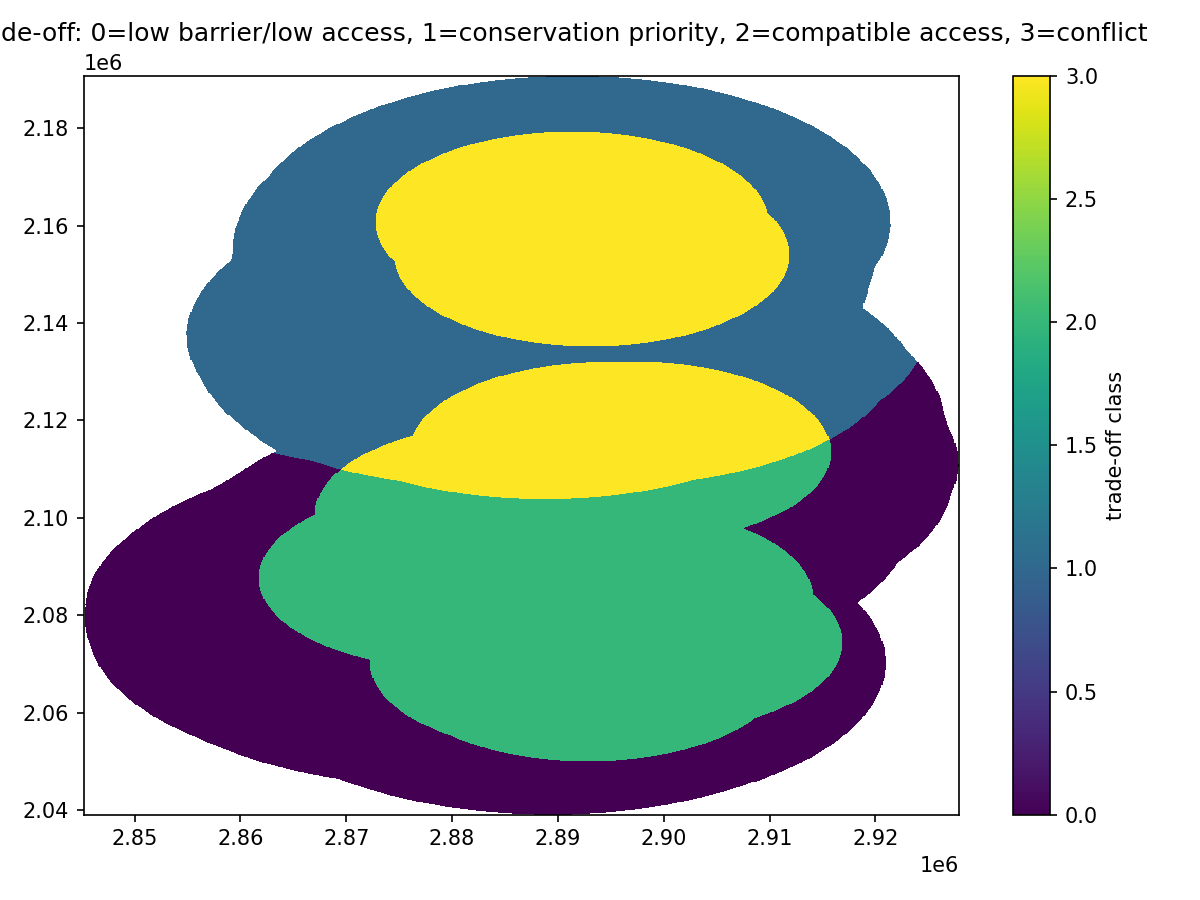

In [11]:
%run build_tradeoff_maps.py
generate_maps._plot_raster(config.OUTPUT_RASTERS / "road_tradeoff_class.tif",
    "Road trade-off: 0=low barrier/low access, 1=conservation priority, 2=compatible access, 3=conflict",
    "viridis", out_name="07_road_tradeoff.png", cbar_label="trade-off class")
display(Image(str(config.OUTPUT_MAPS / "07_road_tradeoff.png")))

  wrote 08_waterway_tradeoff.png


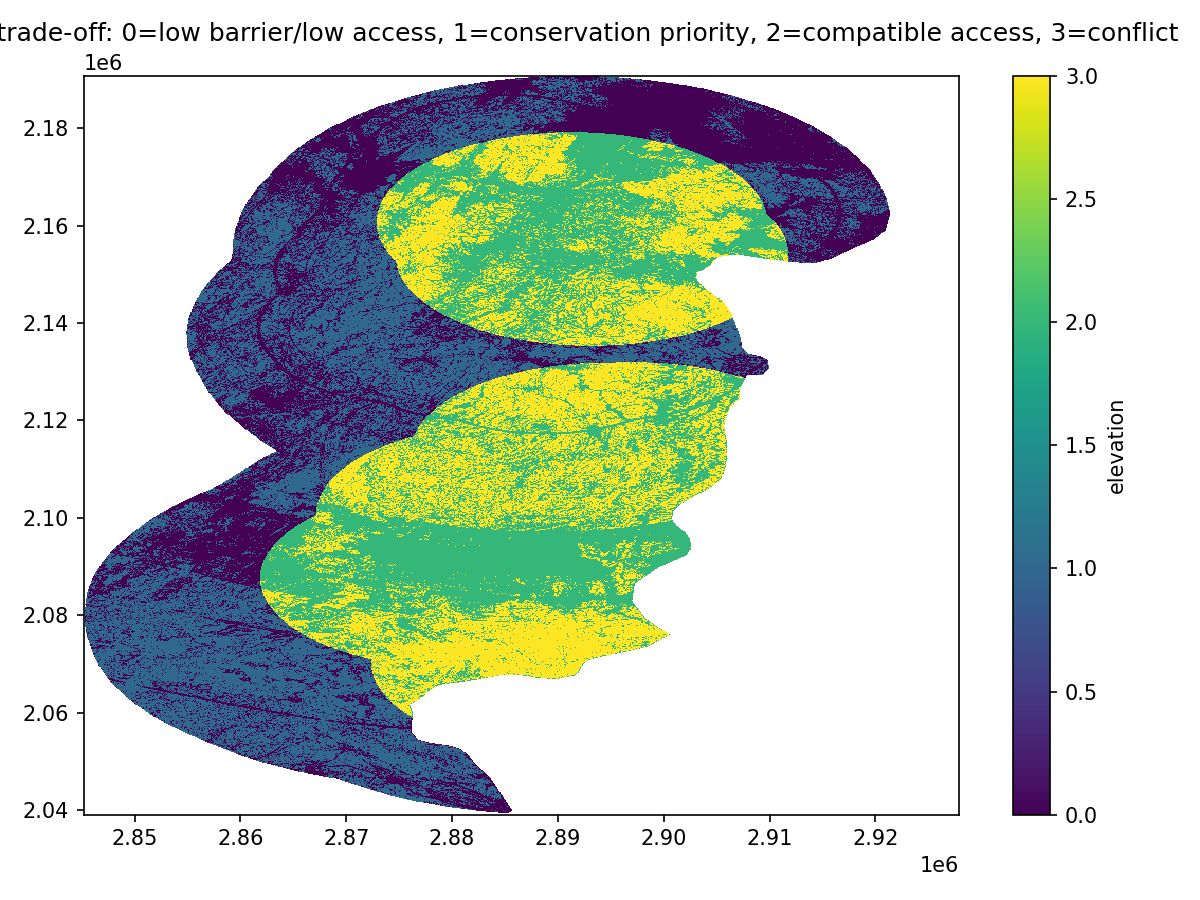

In [12]:
generate_maps._plot_raster(config.OUTPUT_RASTERS / "waterway_tradeoff_class.tif",
    "Waterway trade-off: 0=low barrier/low access, 1=conservation priority, 2=compatible access, 3=conflict",
    "viridis", out_name="08_waterway_tradeoff.png", cbar_label="trade-off class")
display(Image(str(config.OUTPUT_MAPS / "08_waterway_tradeoff.png")))

## Land tenure context

Neither this repo nor the sibling `data-management` repo had a land-tenure layer, so this was pulled fresh from two official online sources: **Faia Brava**, the private nature reserve in the Greater Côa Valley associated with Rewilding Portugal / Rewilding Europe (boundary via OpenStreetMap, sourced from WDPA, legal basis Aviso n.º 26026/2010), and **ICNF's official hunting-zone cadastre** ("zonas de caça" — municipal ZCM, associative ZCA, touristic/private ZCT — via ICNF's own WFS, `si.icnf.pt`, layer `BDG:zonas_caca`).

This is deliberately **not** folded into the resistance surfaces above. A fenced touristic hunting estate managed for game density could be a real barrier to free movement; a well-managed associative zone might not be much different from the surrounding landscape; Faia Brava is presumably an asset, being rewilding-aligned, but this project has no first-hand knowledge of any specific estate's actual management. Mapped as context for a judgement call, not pre-decided by the model.

Private reserves: 1 (Faia Brava)
Hunting zones (ICNF zonas de caça): 318
fig_ord
ZCA    188
ZCM     96
ZCT     34
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/land_tenure.gpkg
  wrote 02_land_tenure.png


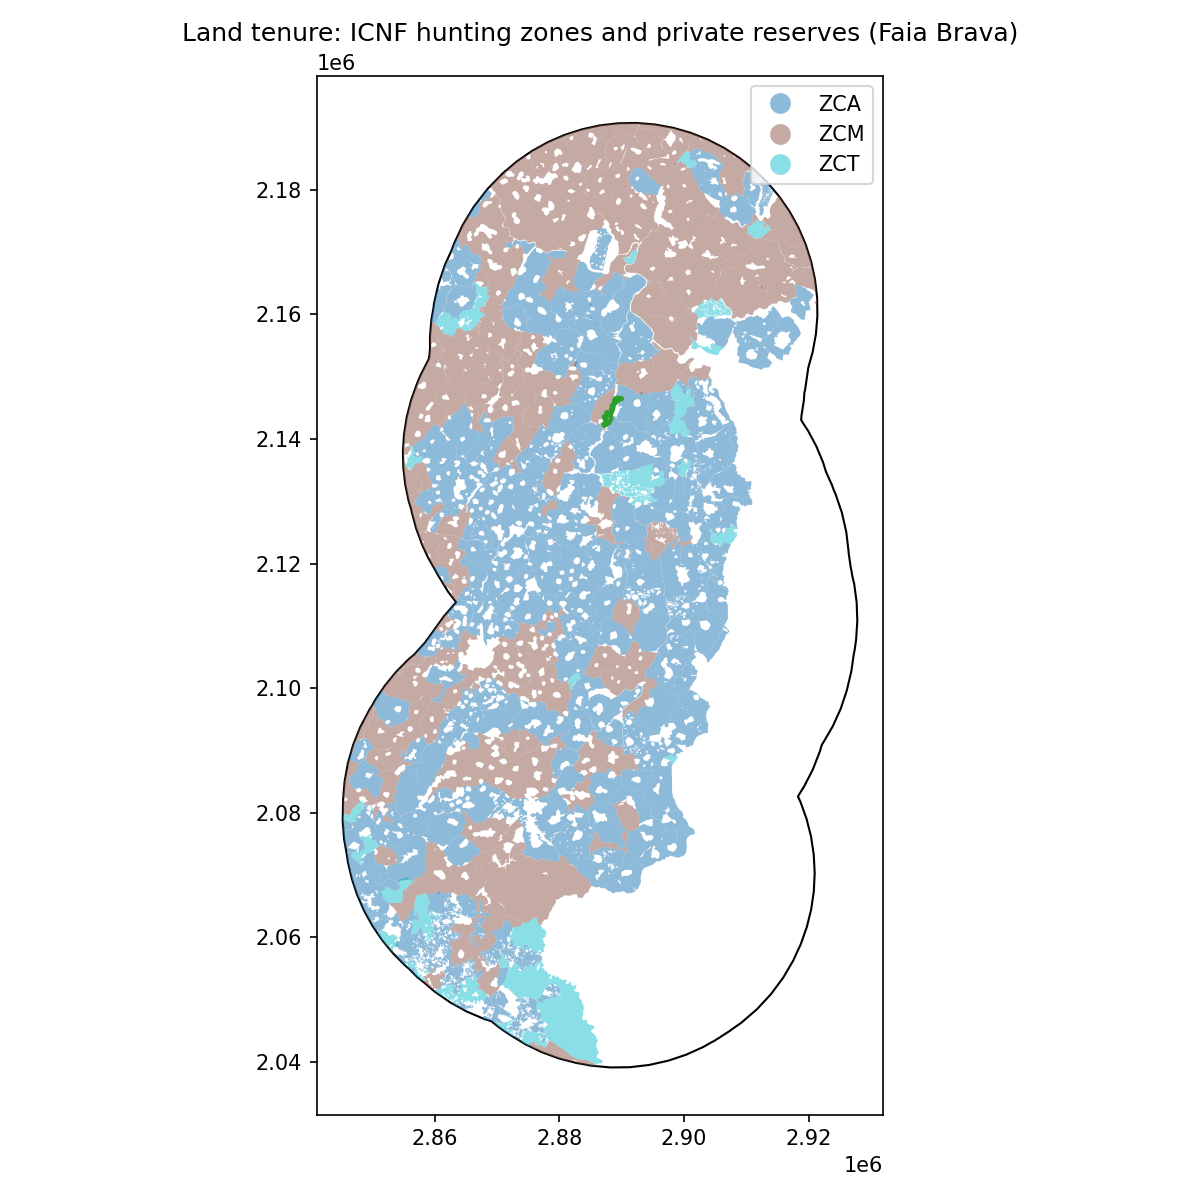

In [13]:
%run acquire_reserves_and_hunting_zones.py
generate_maps.map_02_land_tenure()
display(Image(str(config.OUTPUT_MAPS / "02_land_tenure.png")))

In [14]:
%run acquire_tourism_sites.py

not_yet_visited: 3 sites
potential_ecotourism_sites: 6 sites
                                                  name  connectivity_value          corridor_note
                               Pontao Manuel Jose weir            0.935075  low-connectivity zone
Nascente do Rio Coa / Estacao de Biodiversidade, Foios            1.003796 high-connectivity zone
                          Penascosa rock art reception            1.170632 high-connectivity zone
                       Praia Fluvial de Vale das Eguas            0.948619  low-connectivity zone
                       Praia Fluvial de Rapoula do Coa            0.972280 high-connectivity zone
                              Lageosa (Sorraia horses)            1.010241 high-connectivity zone
Wrote /home/linda/Documents/myData/Solo-field-illustrator-project-for-Rewilding-Portugal/research/eco-connectivity/data/processed/tourism_sites.gpkg


## Eco-tourism and safe-and-just

### Human-wildlife conflict beyond farmers

The Survey123 barrier form already tracks farmer-facing conflict (fences, livestock, agricultural boundaries — see `survey123/metadata.md`). This section adds the recreational side, which the field notes don't yet cover directly: people using the praia fluviais (Rapoula, Vale das Éguas) and the Fóios trail share the same corridor the Land and Water groups model above. Overlaying the Land connectivity output onto these visitor sites (using the same access-value kernel as the road/waterway trade-off maps, section above) flags where higher-suitability zones for less-visible fauna — wildcat, otter, and wild boar (present locally per field notes, though not itself modelled here) — coincide with concentrated visitor presence. This is a stewardship and signage question (seasonal notices, keeping dogs leashed near otter holts), not an argument against access; the connectivity model says nothing about actual encounter risk, only about where suitable habitat and visitor infrastructure happen to overlap.

### Eco-tourism siting, read against the corridor

Candidate eco-tourism development (new interpretive stops, expanded trail infrastructure) should avoid siting itself in the combined connectivity map's "pinch points" — narrow high-flow corridor stretches where added infrastructure or foot traffic would do disproportionate fragmentation damage relative to a wide, already-permeable stretch. The **just** half of that same question is about who reaches the corridor at all: candidate sites are worth checking against whether they're reachable from more than one municipality/access point (this project's own visited-sites list already spans Almeida, Sabugal, and Vila Nova de Foz Côa municipalities) rather than concentrating investment wherever is currently easiest to reach — this repo has no visitor-origin or accessibility-infrastructure data to check that claim quantitatively, so it's stated as a design principle for future site selection, not a finding.

### What this notebook does not claim

No demographic, disability-access, or visitor-origin data exists anywhere in this project. "Just" here means checking recommendations against multi-site reachability and against not concentrating access at the expense of the corridor — not a claim of having assessed equity or inclusion directly. That gap is worth naming rather than papering over with language that implies more than the data supports.

## Validation

Basic checks only — grid/CRS alignment across every output raster, and a direction-of-effect check (connectivity should be lower near roads than far from them, for the Land group). Neither is a statistical validation; see the Method section's caveats.

In [15]:
%run validate_results.py

Grid alignment: OK (5 rasters checked)
Land connectivity near roads (<25th pct distance): mean 0.987
Land connectivity far from roads (>75th pct distance): mean 1.002
  Direction as expected: lower connectivity near roads.
Survey123 visited sites available for spot-check: 12 (barrier-type/permeability fields are free text in this prototype export - see acquire_field_observations.py docstring - so this is a manual read, not automated).


## Handoff

The rasters in `output/rasters/` and the maps in `output/maps/` are the finished products this notebook exists to produce — per `storyMaps/scratch.md`'s own stated split, they belong in the closing "Two Rivers, Two Stories" chapter of the ArcGIS StoryMap as finished map images, not as working data the StoryMap re-derives. The QGIS project (`qgis/coa_eco_connectivity_ecotourism.qgz`) carries the same layers into an interactive form for further cartographic work, including the visited/not-yet-visited/eco-tourism layers this notebook doesn't build.

**Known limitations, collected in one place:**
- One suitability model and one parameter set per group, not Prima et al.'s full ensemble/uncertainty sweep.
- No held-out validation split; no movement-tracking data to check against.
- Air-group suitability likely reflects recording density more than true habitat preference.
- Land-group occurrence data is thin (38 usable points) after the permissive coordinate-uncertainty filter this project needed.
- Waterway barrier severity reuses the Water resistance surface rather than a dedicated dam/weir layer.
- Land-tenure layer (reserves, hunting zones) is descriptive context, not a validated barrier/asset classification.
- "Just" is checked against reachability and corridor impact only — no equity/accessibility data exists in this project to assess more directly.